## 1. Problem Statement
###### This project understands how the student's performance is affected by other variables such as Gender, Ethinicity, Parental level of education and Test preparation course

In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/Users/shuchi/Desktop/MLProjects/end2end_project/notebook/data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [8]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### Insights

All means are very close to each, which lie between 65 and 70 
All the standard deviations are within the range of 14 and 16
For maths the minimum score is 0 while for reading and writing its quite higher 

## Exploring Data

In [14]:
print("Categories in 'gender' variable: ", end = '')
print(df['gender'].unique())

print("Categories in 'race/ethinicity' variable: ", end = '')
print(df['race_ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end = '')
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end = '')
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end = '')
print(df['test_preparation_course'].unique())

Categories in 'gender' variable: ['female' 'male']
Categories in 'race/ethinicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test preparation course' variable: ['none' 'completed']


In [12]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [17]:
# define numerical and categorical columns
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format (len(numerical_features), numerical_features))
print('We have {} categorical features : {}'.format (len(categorical_features), categorical_features))


We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


#### Adding columns for Total score and Average

In [18]:
df['Total_Score'] = df['reading_score'] + df['writing_score'] + df['math_score']
df['Average'] = df['Total_Score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [21]:
reading_full = df[df['reading_score']==100]['Average'].count()
writing_full = df[df['writing_score']==100]['Average'].count()
math_full = df[df['math_score']==100]['Average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Reading: {reading_full}')
print(f'Number of students with full marks in Writing: {writing_full}')



Number of students with full marks in Maths: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


- We have seen that students have performed worst in maths .
- Best in reading

## Visualizing the Data 

#### Histogram and KDE

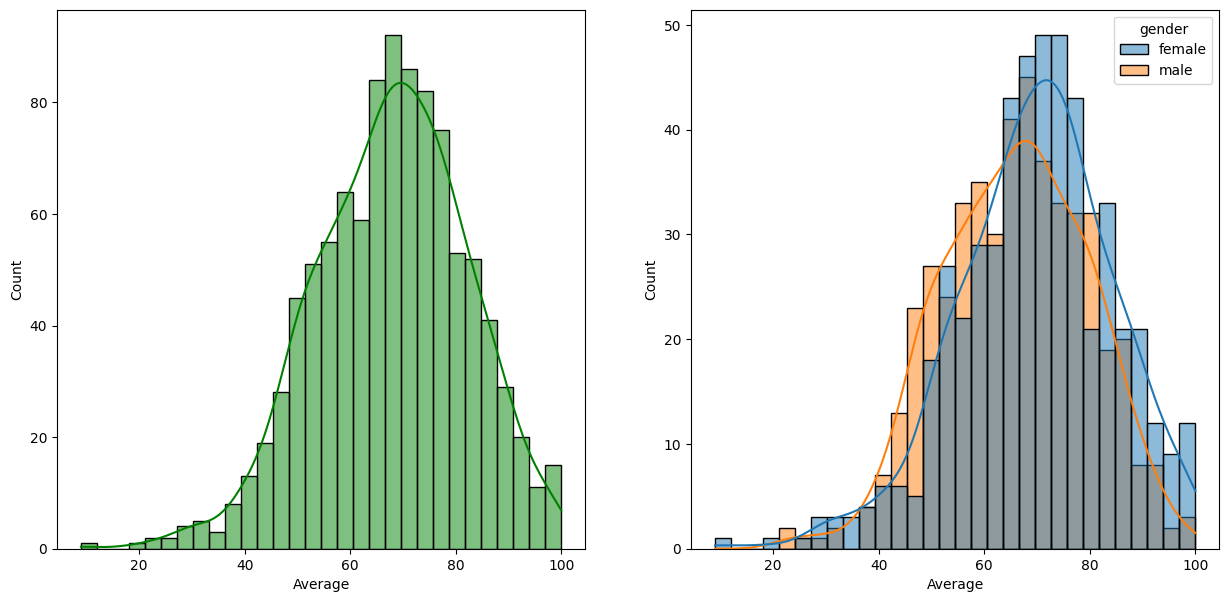

In [32]:
figs, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(121)
sns.histplot(data = df, x = 'Average', bins = 30,  color = 'g', kde = True)
plt.subplot(122)
sns.histplot(data= df, x = 'Average', bins = 30, kde = True, hue = 'gender')
plt.show()


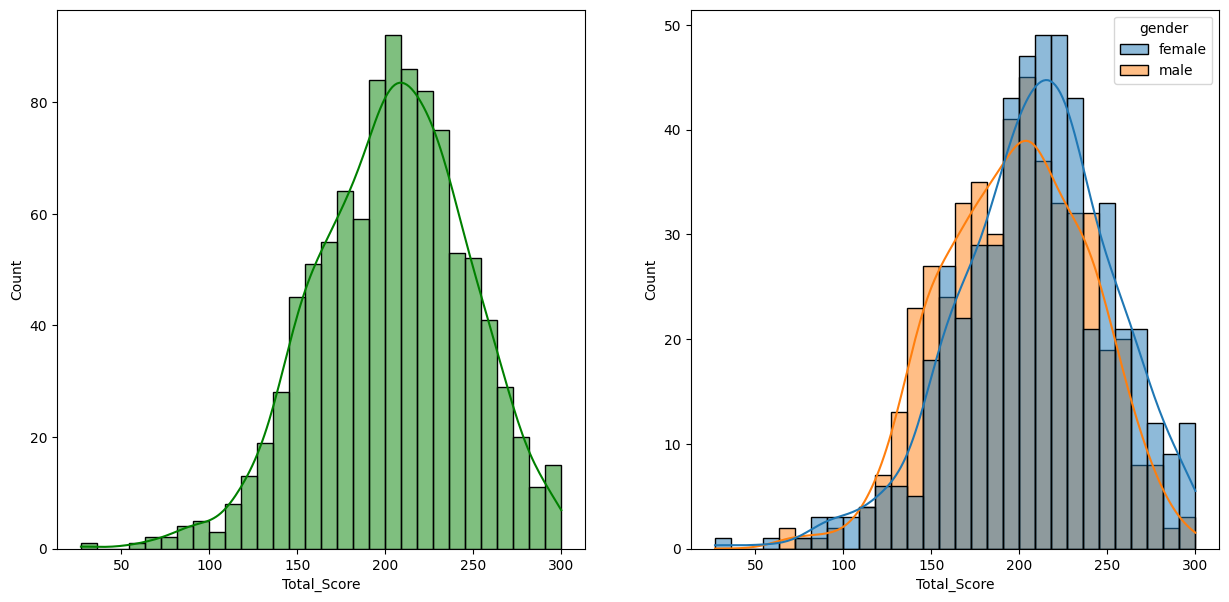

In [33]:
figs, axs = plt.subplots(1,2, figsize = (15,7))
plt.subplot(121)
sns.histplot(data = df, x = 'Total_Score', bins = 30,  color = 'g', kde = True)
plt.subplot(122)
sns.histplot(data= df, x = 'Total_Score', bins = 30, kde = True, hue = 'gender')
plt.show()


Female students are tend to perform better than male students.

<Axes: xlabel='Average', ylabel='Count'>

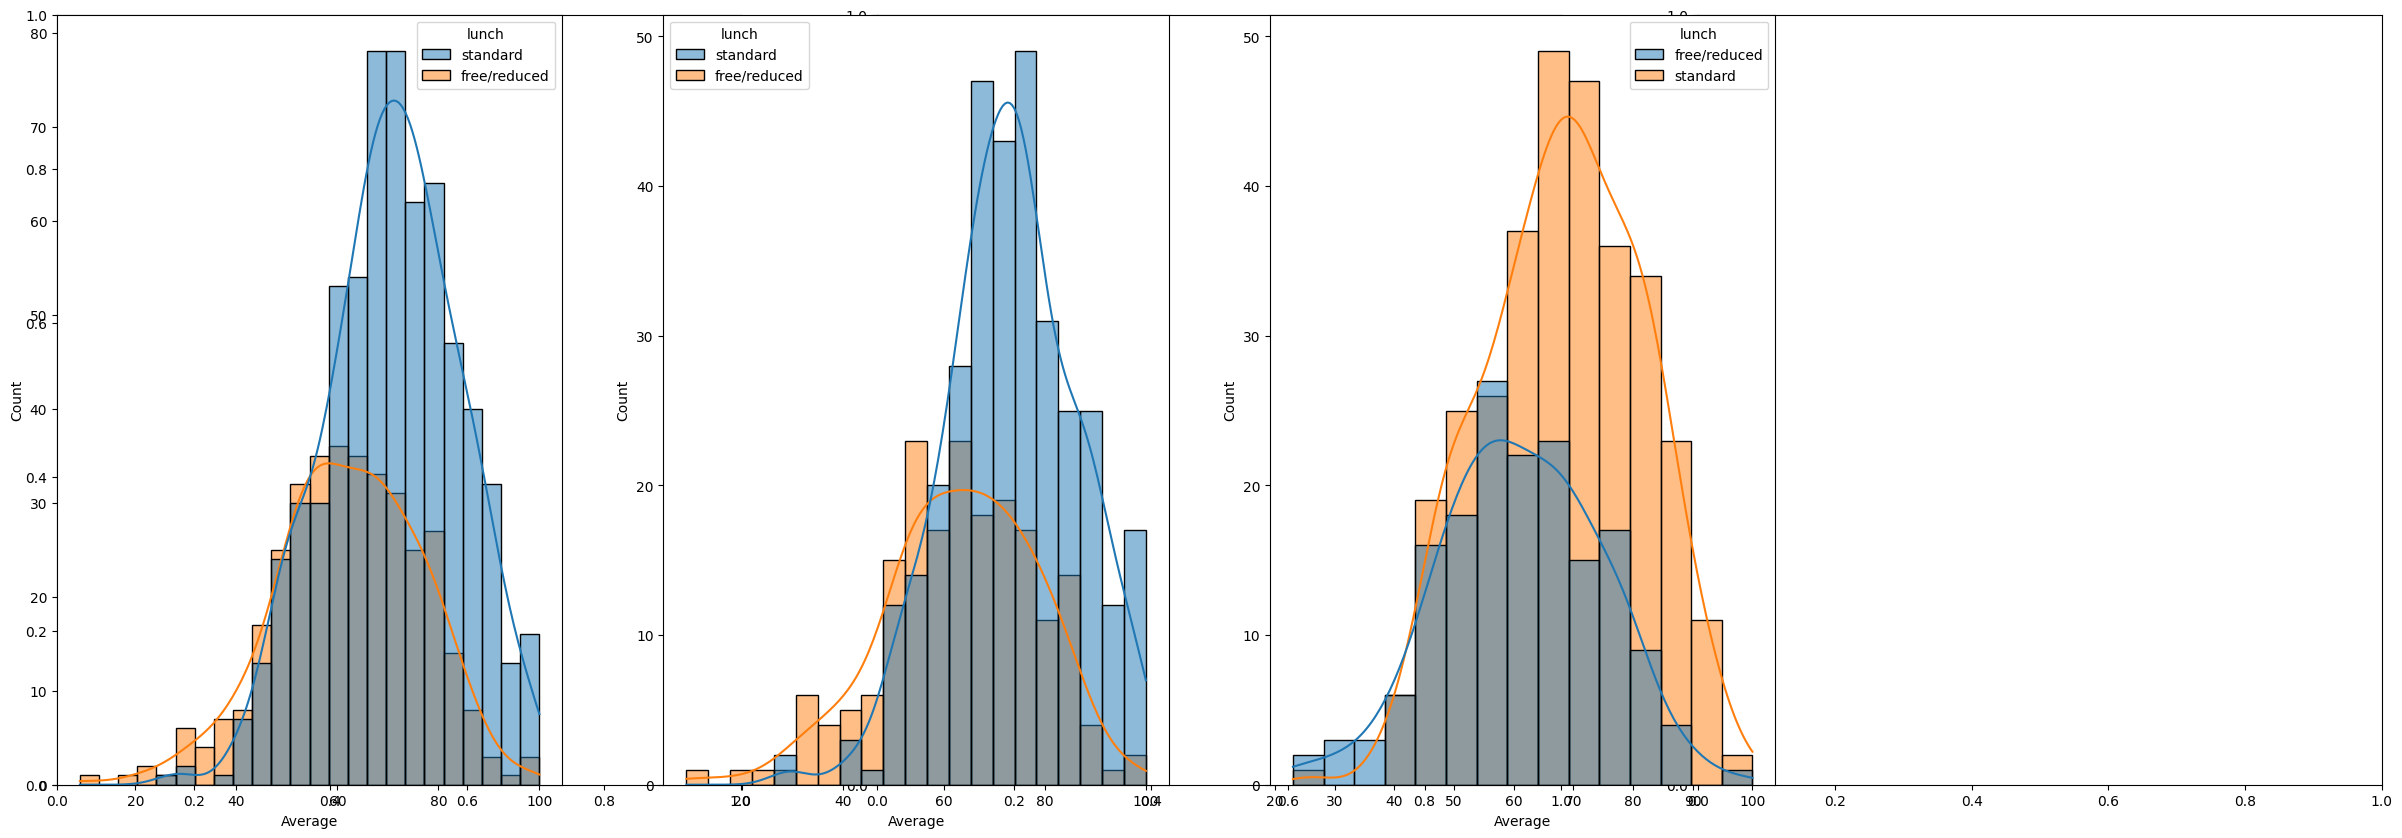

In [39]:
figs, axs = plt.subplots(1,3, figsize = (30,10))
plt.subplot(141)
sns.histplot(data= df, x = 'Average', kde = True, hue = 'lunch')
plt.subplot(142)
sns.histplot(data = df[df.gender =='female'], x = 'Average', kde = True, hue = 'lunch')
plt.subplot(143)
sns.histplot(data = df[df.gender =='male'], x = 'Average', hue = 'lunch', kde = True)

Standard lunch helps perform better in exams be it male or female

<Axes: xlabel='Average', ylabel='Count'>

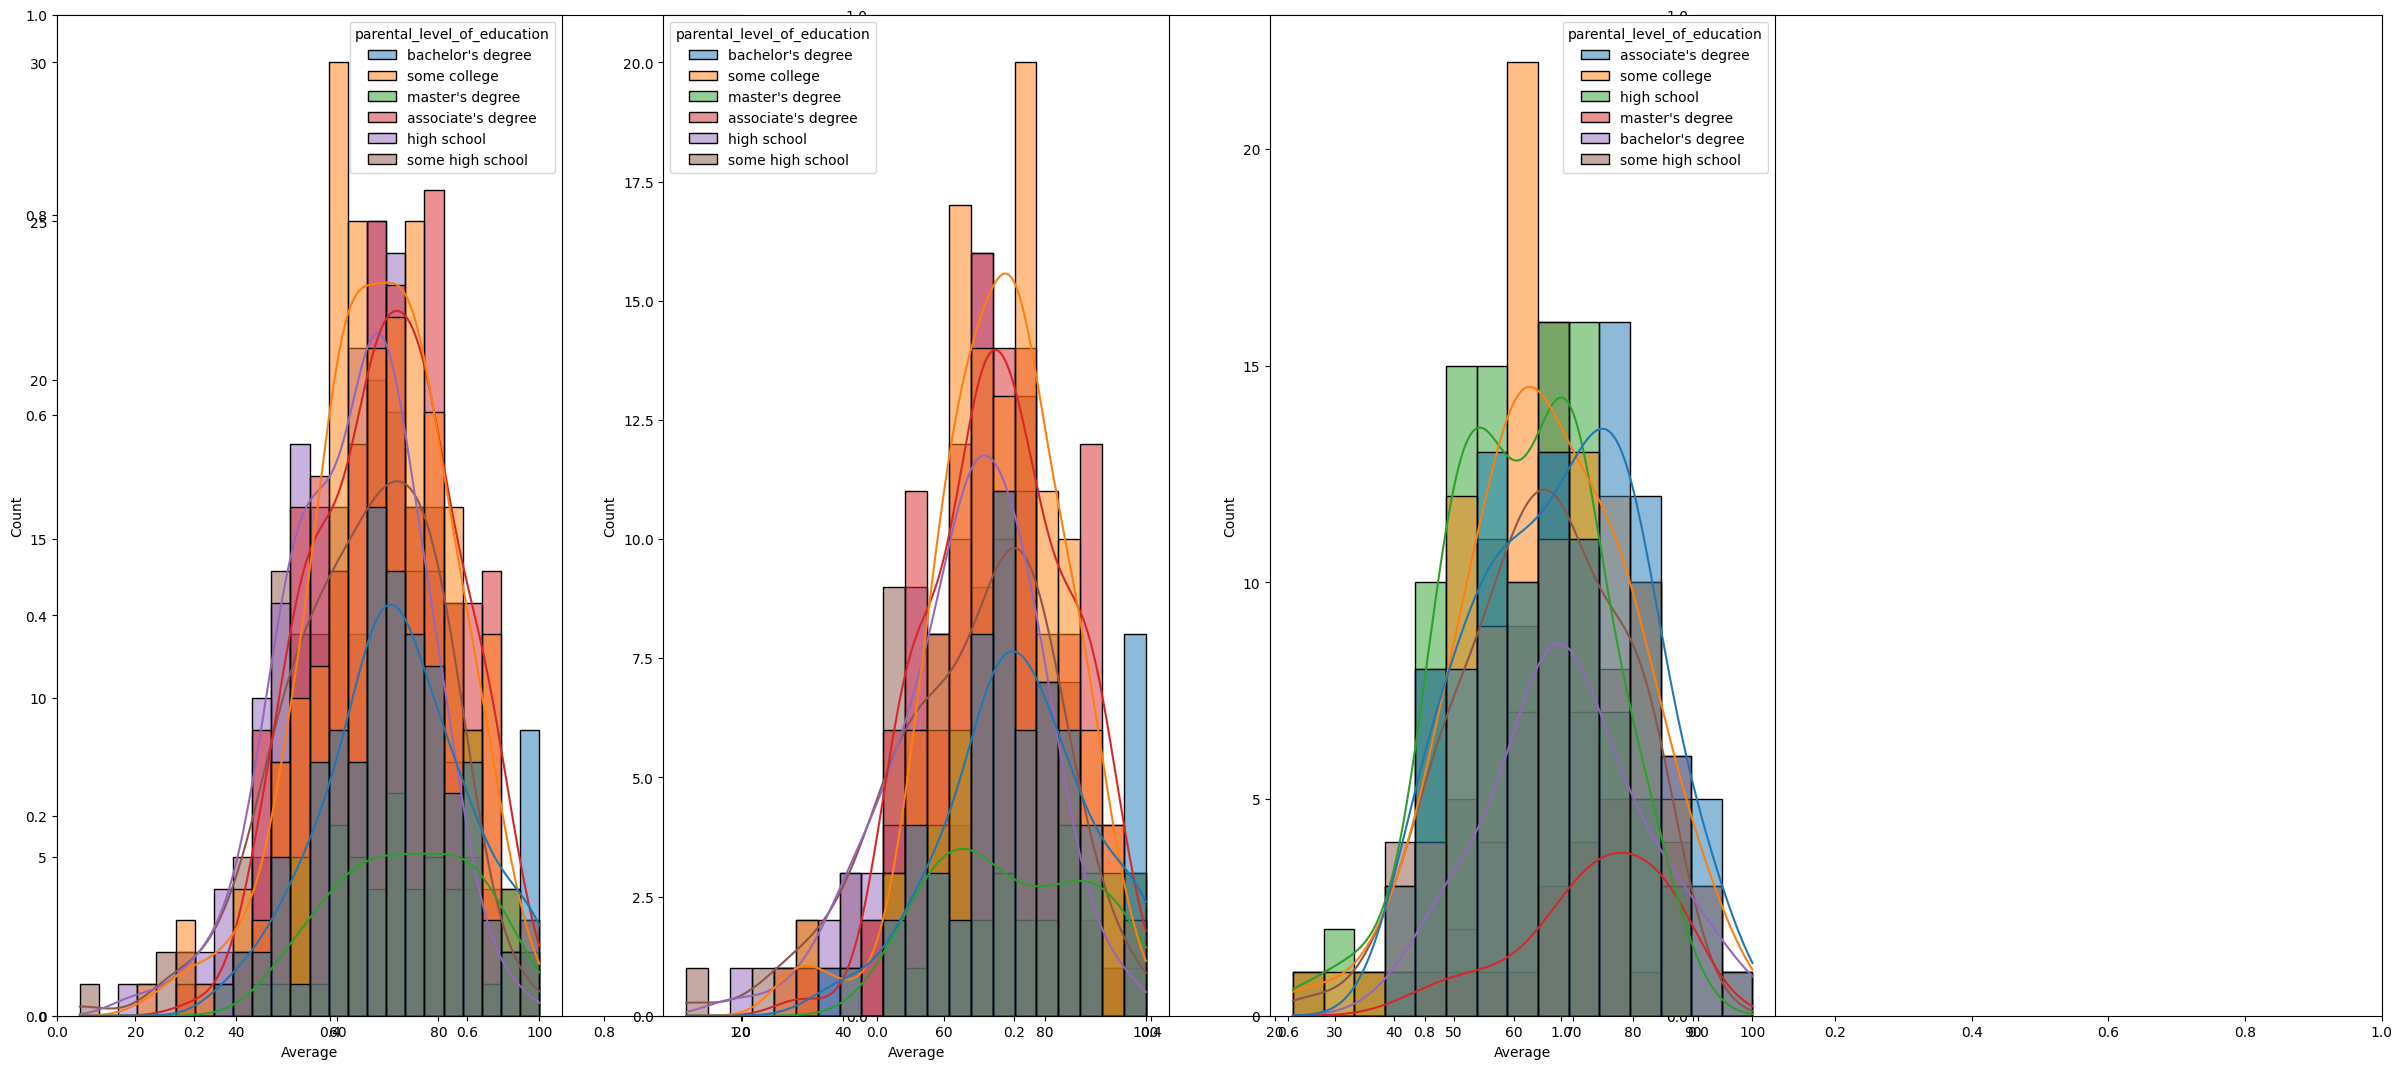

In [42]:
figs, axs = plt.subplots(1,3, figsize = (30,13))
plt.subplot(141)
sns.histplot(data= df, x = 'Average', kde = True, hue = 'parental_level_of_education')
plt.subplot(142)
sns.histplot(data = df[df.gender =='female'], x = 'Average', kde = True, hue = 'parental_level_of_education')
plt.subplot(143)
sns.histplot(data = df[df.gender =='male'], x = 'Average', hue = 'parental_level_of_education', kde = True)

In general parent's degree does not have a significant effect on the performance of the students

<Axes: xlabel='Average', ylabel='Count'>

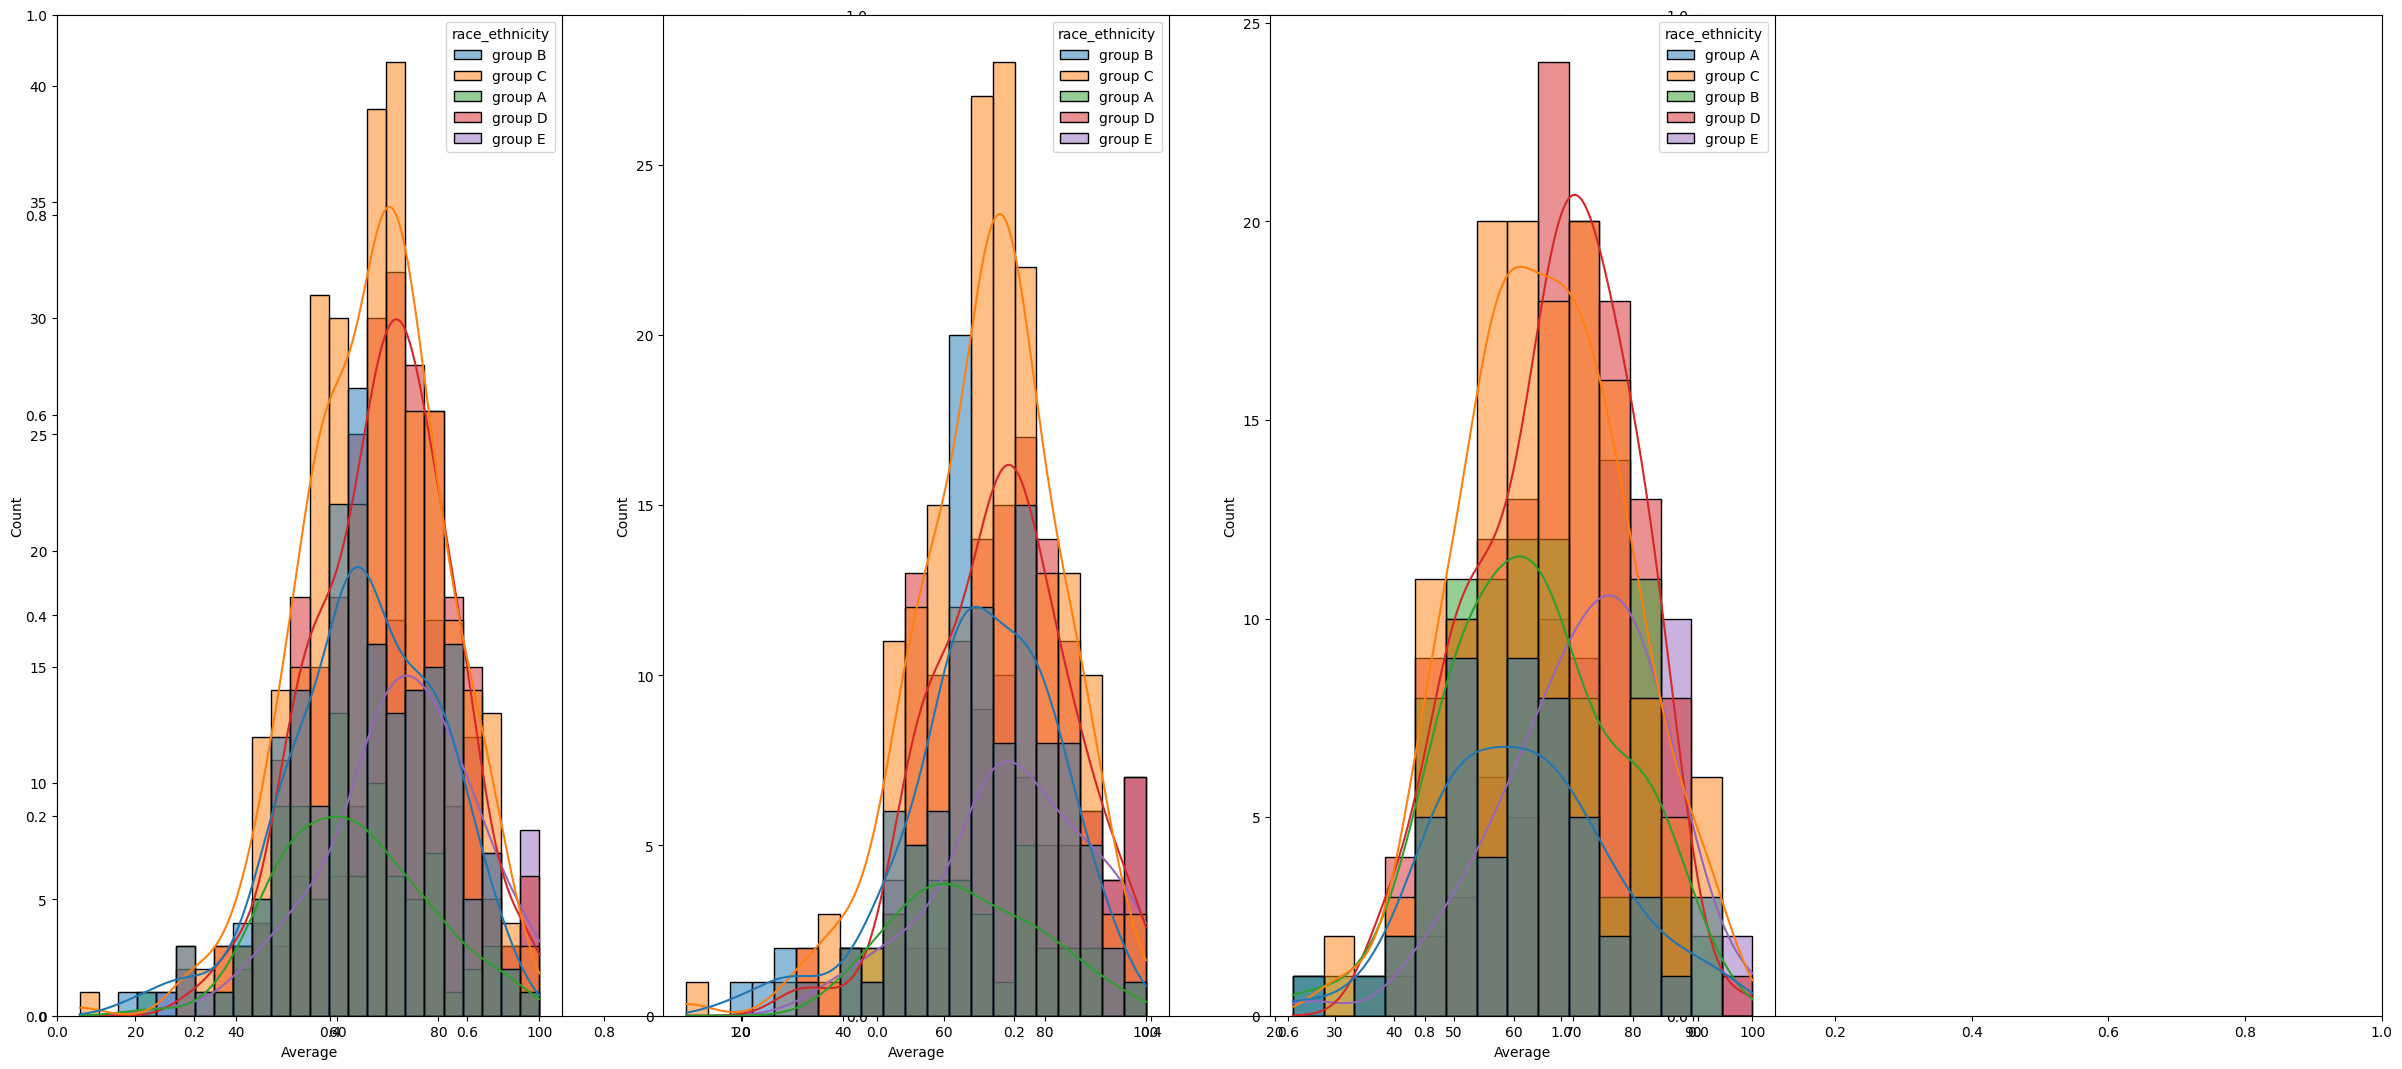

In [47]:
figs, axs = plt.subplots(1,3, figsize = (30,13))
plt.subplot(141)
sns.histplot(data= df, x = 'Average', kde = True, hue = 'race_ethnicity')
plt.subplot(142)
sns.histplot(data = df[df.gender =='female'], x = 'Average', kde = True, hue = 'race_ethnicity')
plt.subplot(143)
sns.histplot(data = df[df.gender =='male'], x = 'Average', hue = 'race_ethnicity', kde = True)

Students of group A and B tend to perform badly irrespective of whether they are male or female

### Maximum score of students in all three subjects

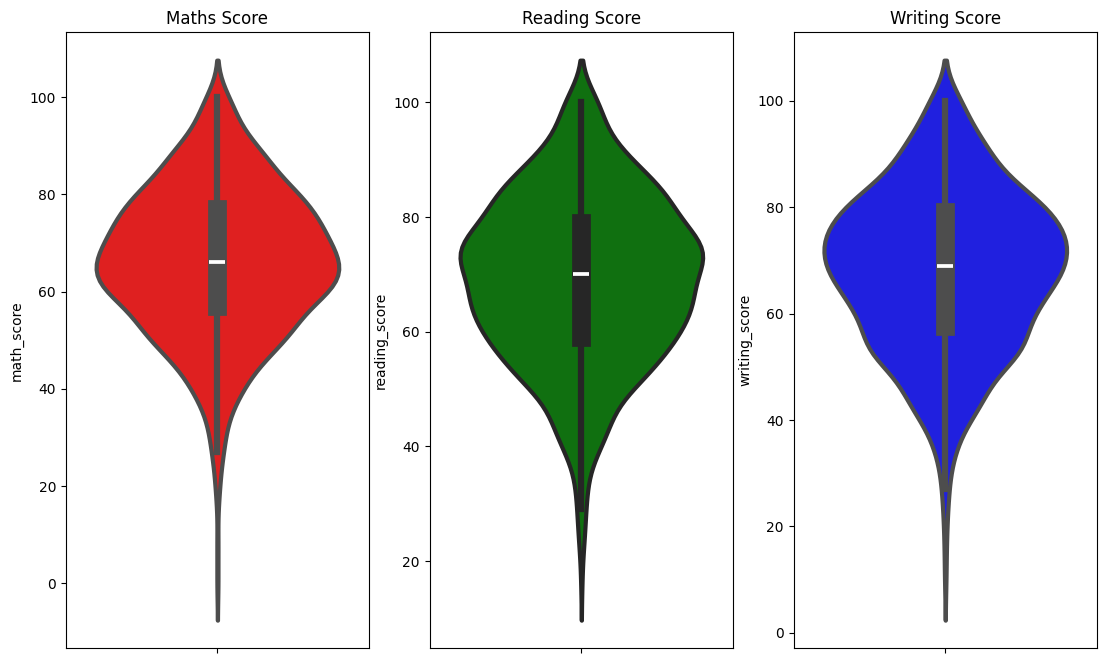

In [51]:
plt.figure(figsize= (18,8))
plt.subplot(1,4,1)
plt.title('Maths Score')
sns.violinplot(y = 'math_score', data= df, color= 'red', linewidth=3)
plt.subplot(1,4,2)
plt.title('Reading Score')
sns.violinplot(y = 'reading_score', data= df, color= 'green', linewidth=3)
plt.subplot(1,4,3)
plt.title('Writing Score')
sns.violinplot(y = 'writing_score', data= df, color= 'blue', linewidth=3)
plt.show()



From this its clear that most of the students for maths are in the range 60-80 while for reading and writing it's 50-80 

#### Multivariate Analysis

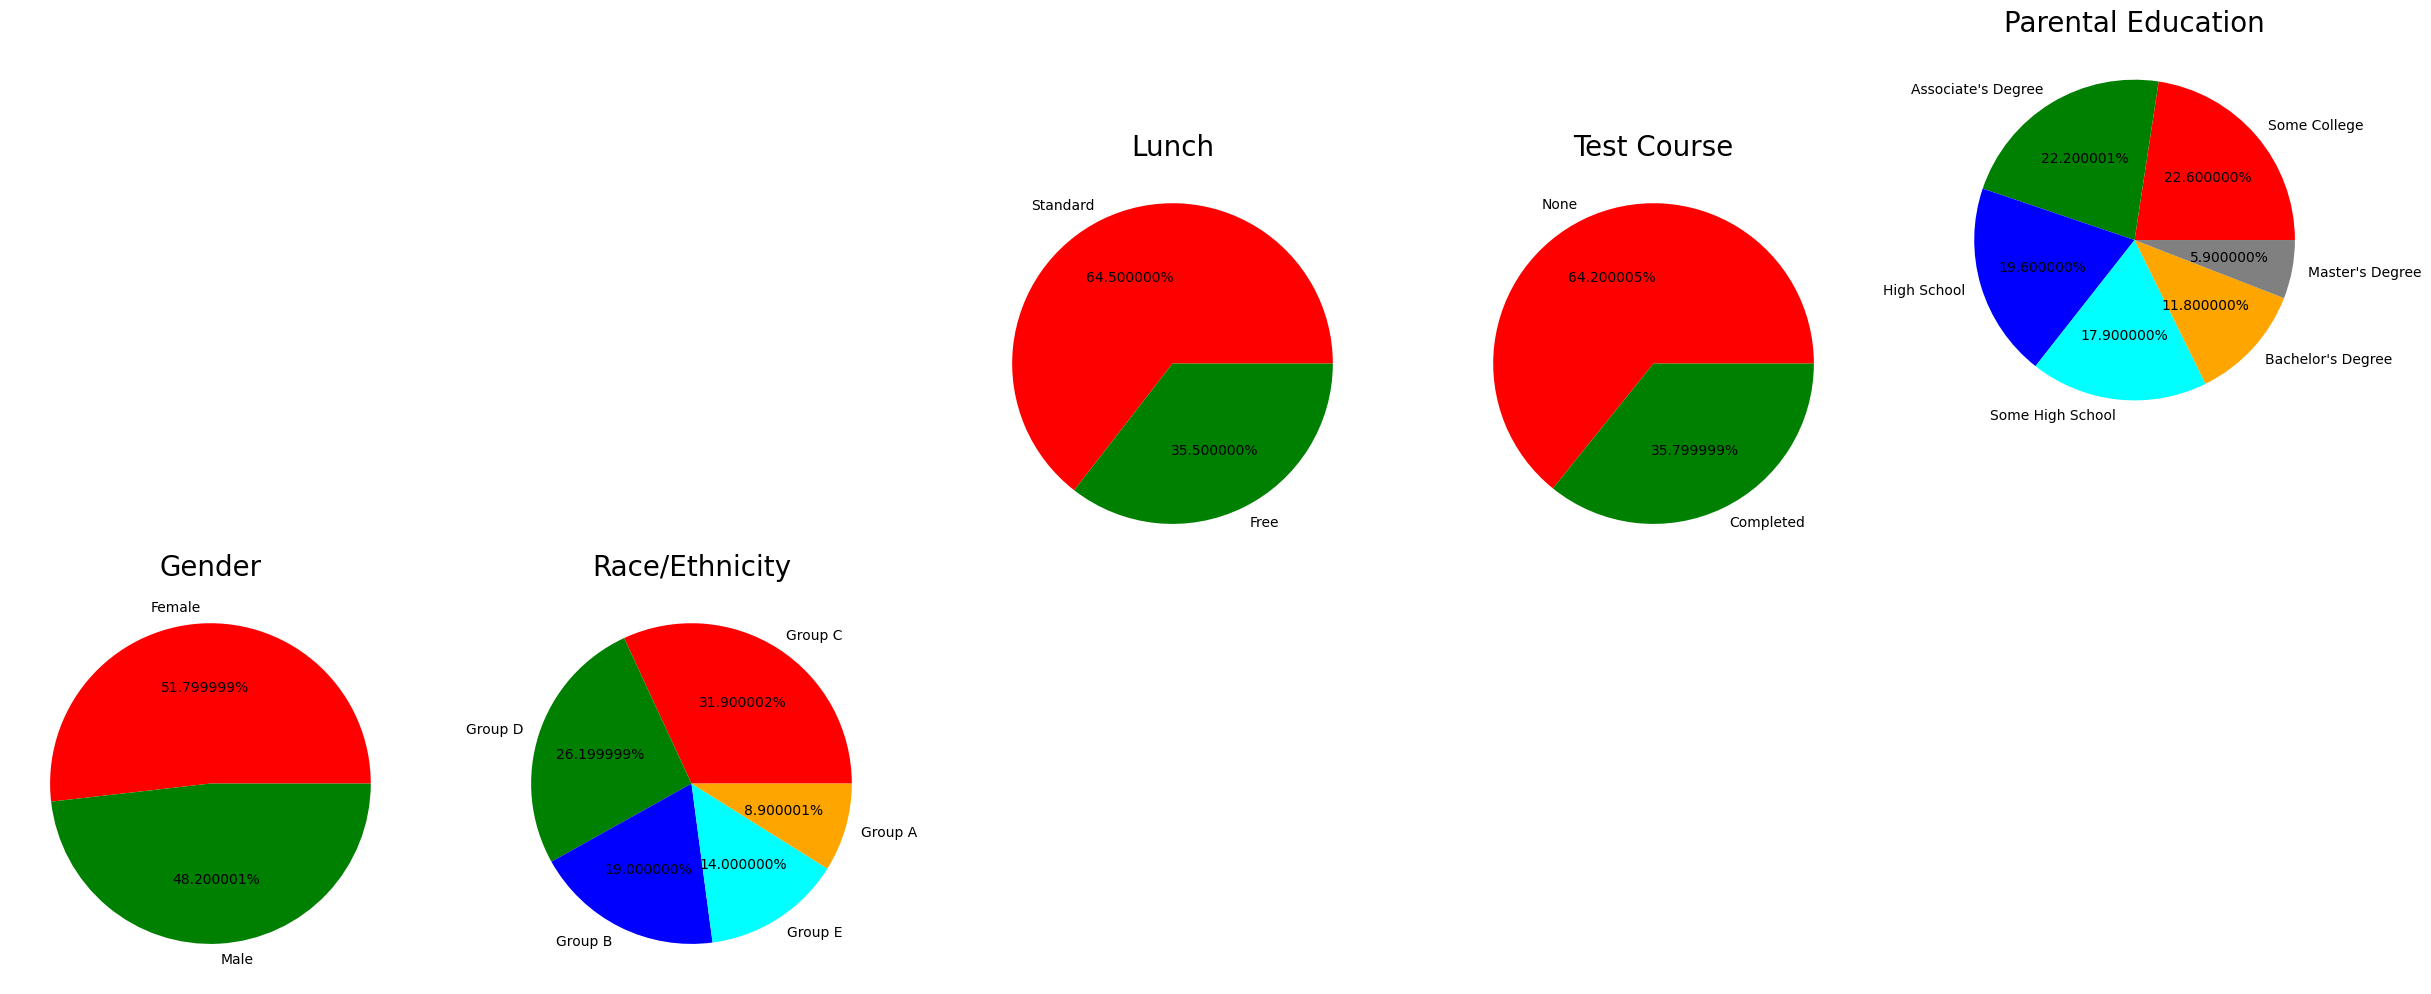

In [64]:
plt.rcParams['figure.figsize']=(30,20)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red', 'green']

plt.pie(size, colors= color, labels=labels, autopct='%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(2, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(2, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(3, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()


- Gender distribution is almost equal.
- Most students belong to Group C.
- Majority of students have standard lunch.
- Most students have not enrolled in any test preparation course.
- Parental education is highest for "Some College", followed by "Associate's Degree".


### Univariate Analysis

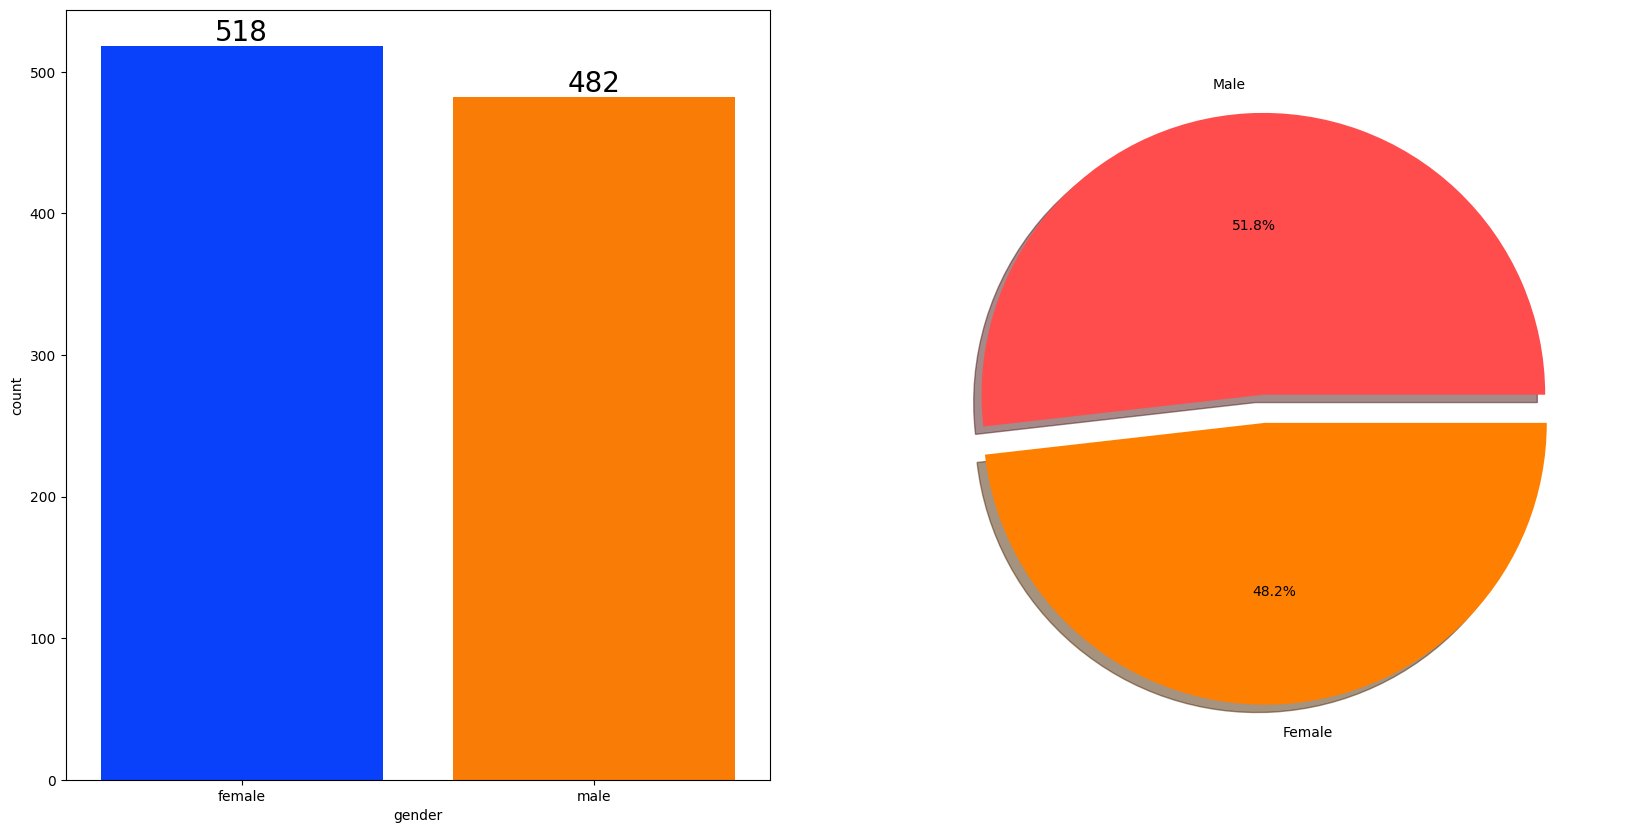

In [67]:
f,ax = plt.subplots(1,2, figsize = (20,10))
sns.countplot(x = df['gender'], data= df, palette= 'bright', ax= ax[0], saturation= 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['gender'].value_counts(),labels = ['Male', 'Female'], explode= [0,0.1], 
        autopct= '%1.1f%%', shadow= True , colors = ['#ff4d4d', '#ff8000'])
plt.show()

Gender has balanced data with female students are 518 and males 482

### Bivariate Analysis

In [71]:
gender_group = df.groupby('gender').mean(numeric_only= True)

In [72]:
gender_group

,math_score,reading_score,writing_score,Total_Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


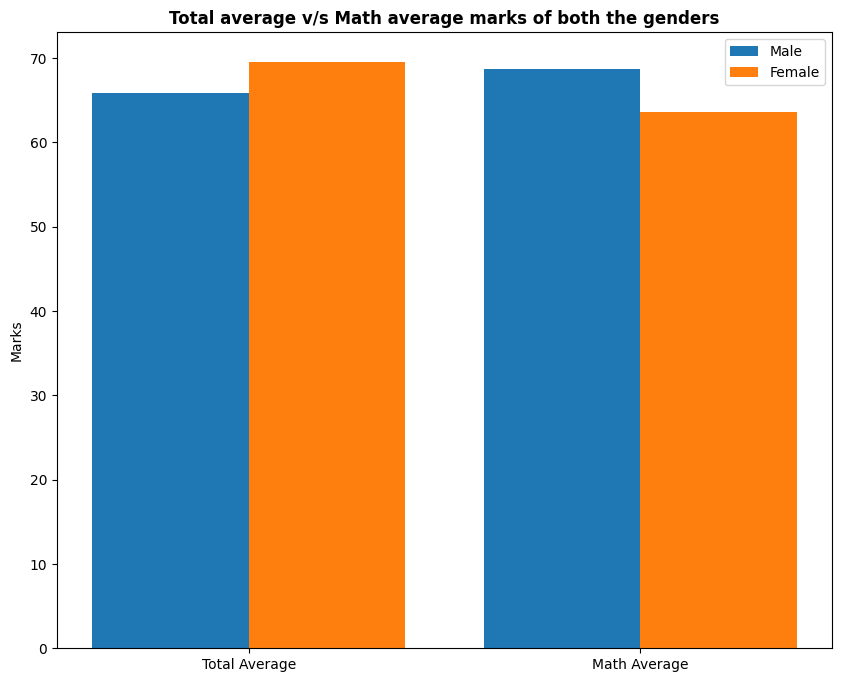

In [74]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['Average'][0], gender_group['math_score'][0]]
male_scores = [gender_group['Average'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

- On an average females have better overall score than males.
- While males have higher math scores than females. 

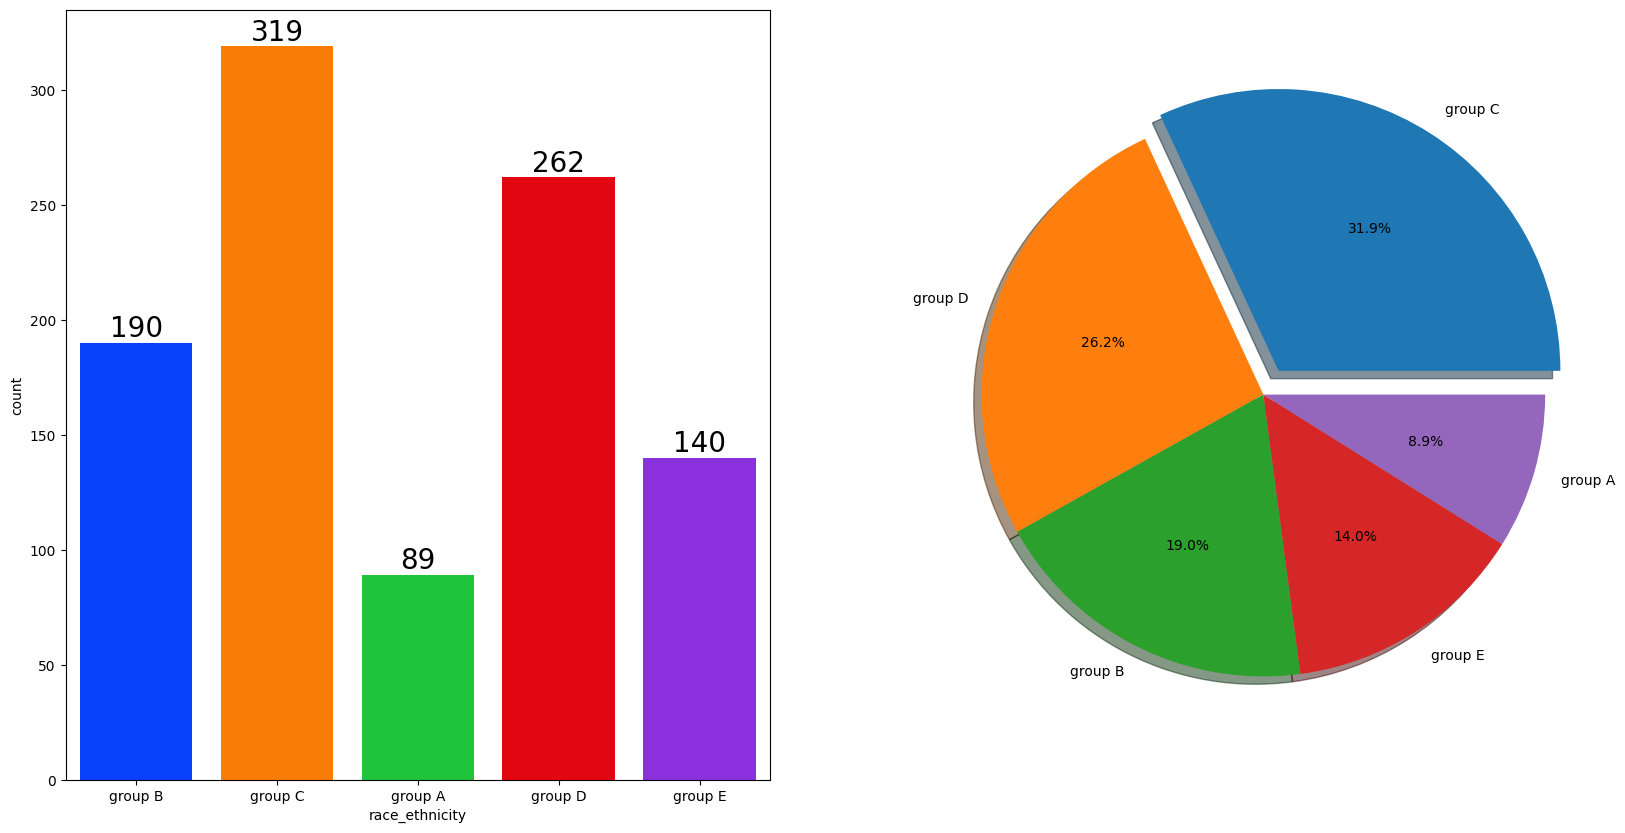

In [76]:
f,ax = plt.subplots(1,2, figsize = (20,10))
sns.countplot(x = df['race_ethnicity'], data= df, palette= 'bright', ax= ax[0], saturation= 0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color = 'black', size = 20)

plt.pie(x = df['race_ethnicity'].value_counts(),labels = df['race_ethnicity'].value_counts().index, 
        explode= [0.1, 0,0,0,0], autopct= '%1.1f%%', shadow= True)
plt.show()

- Most the students belong to Group C and Group D.
- Lowest number of students belong to Group A.

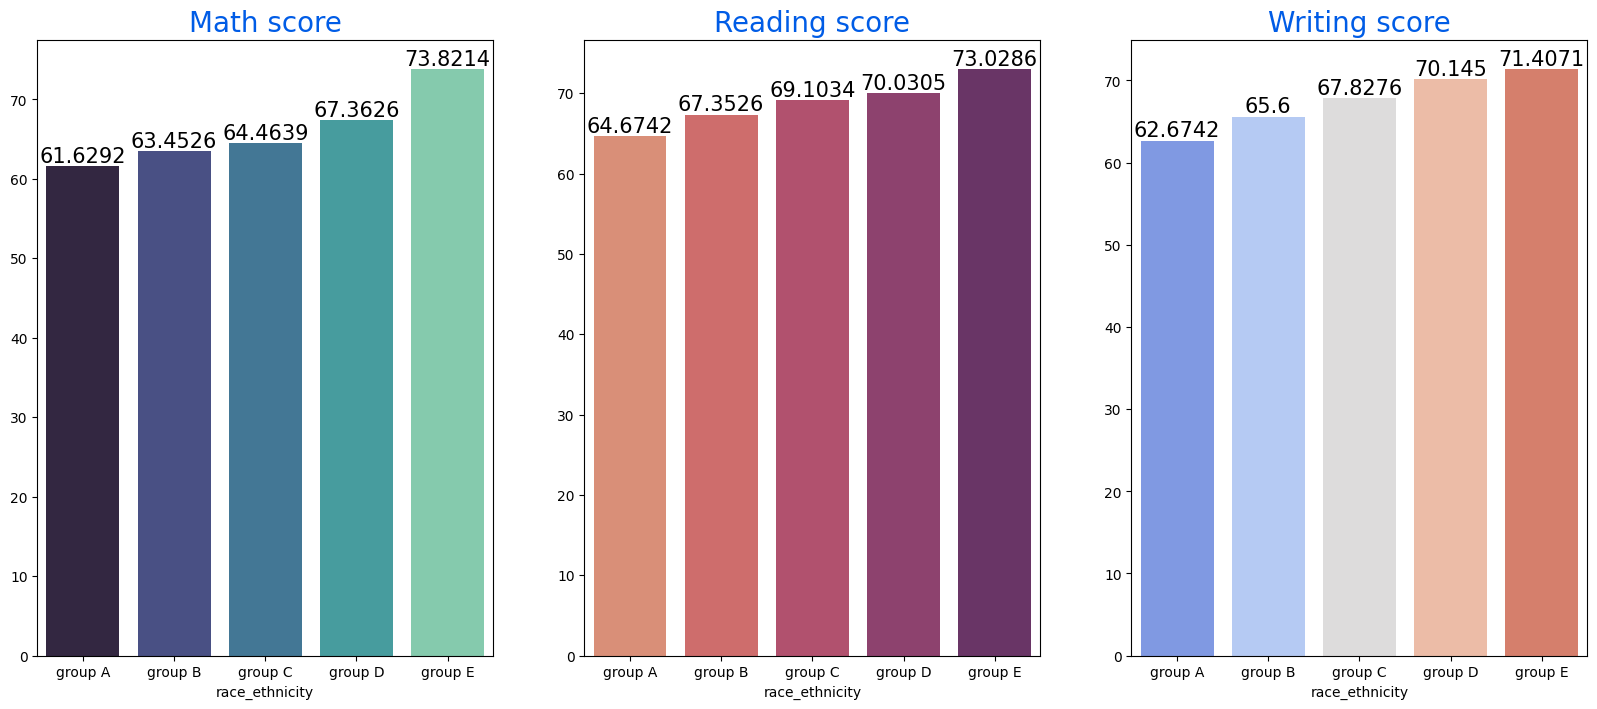

In [77]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

- Group E students have scored the highest marks.
- Group A students have scored the lowest marks.
- Students from a lower Socioeconomic status have a lower avg in all course subjects

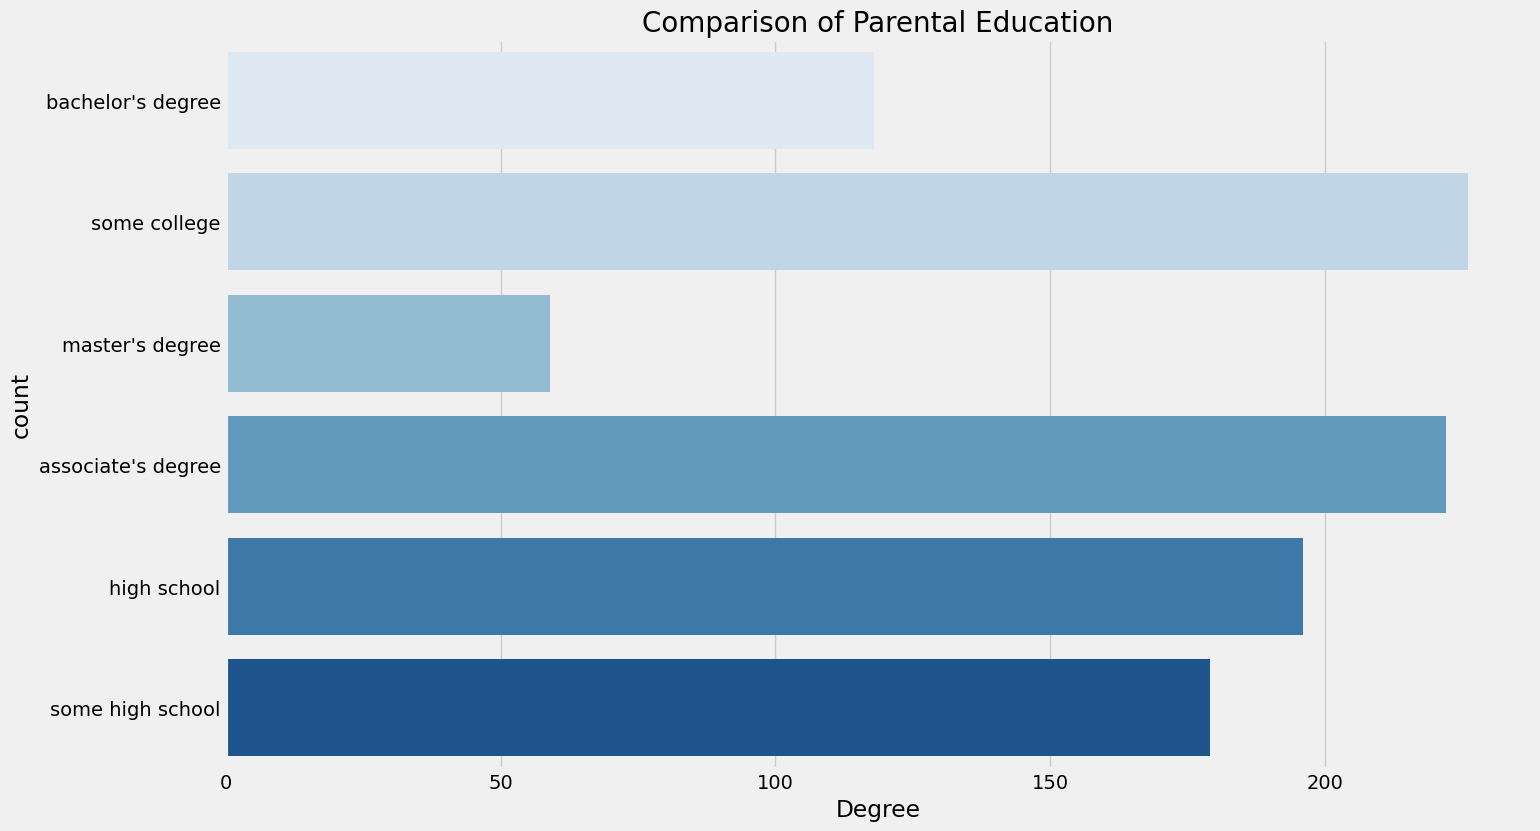

In [78]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

Largest number of parents are from some college.

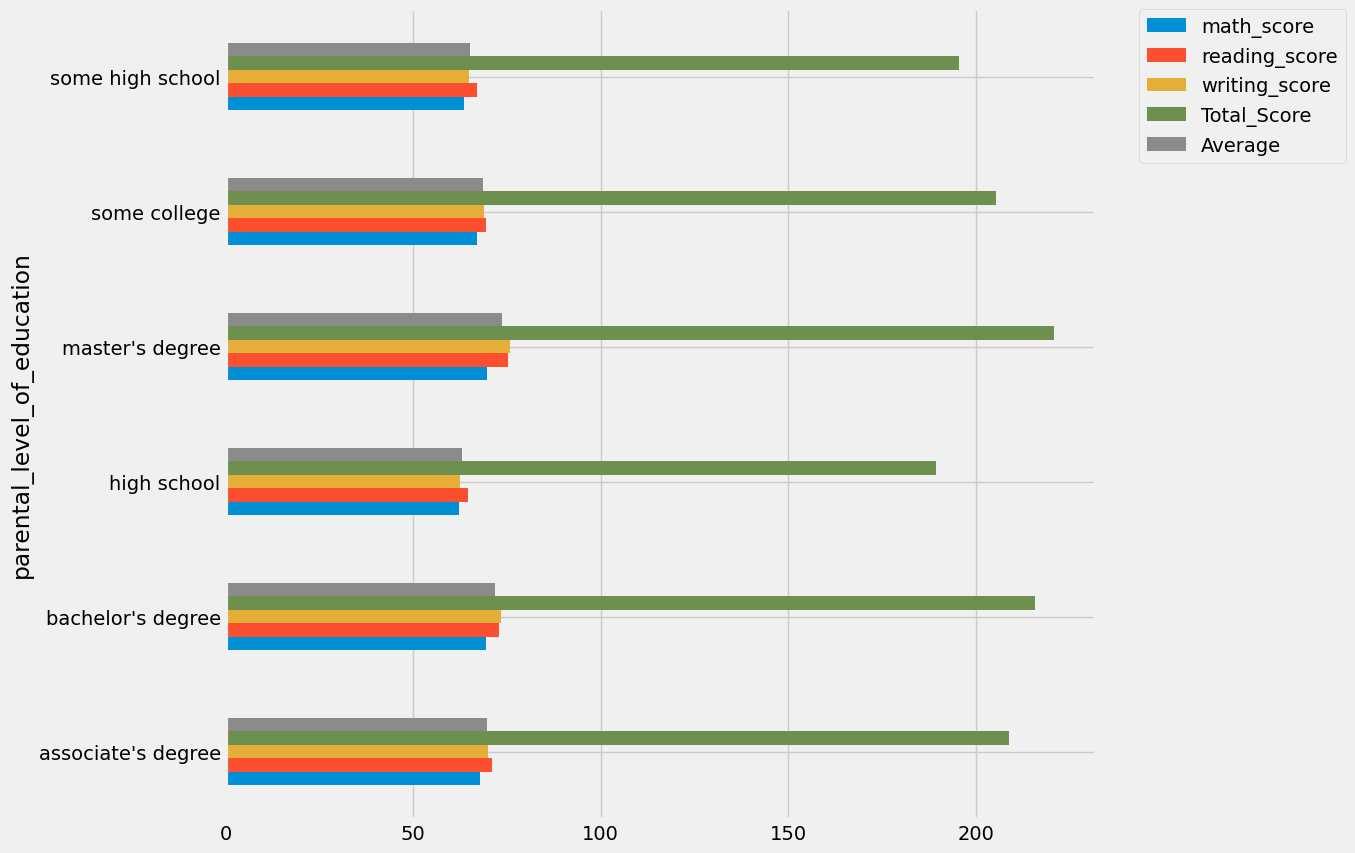

In [80]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

The score of student whose parents possess master and bachelor level education are higher than others.

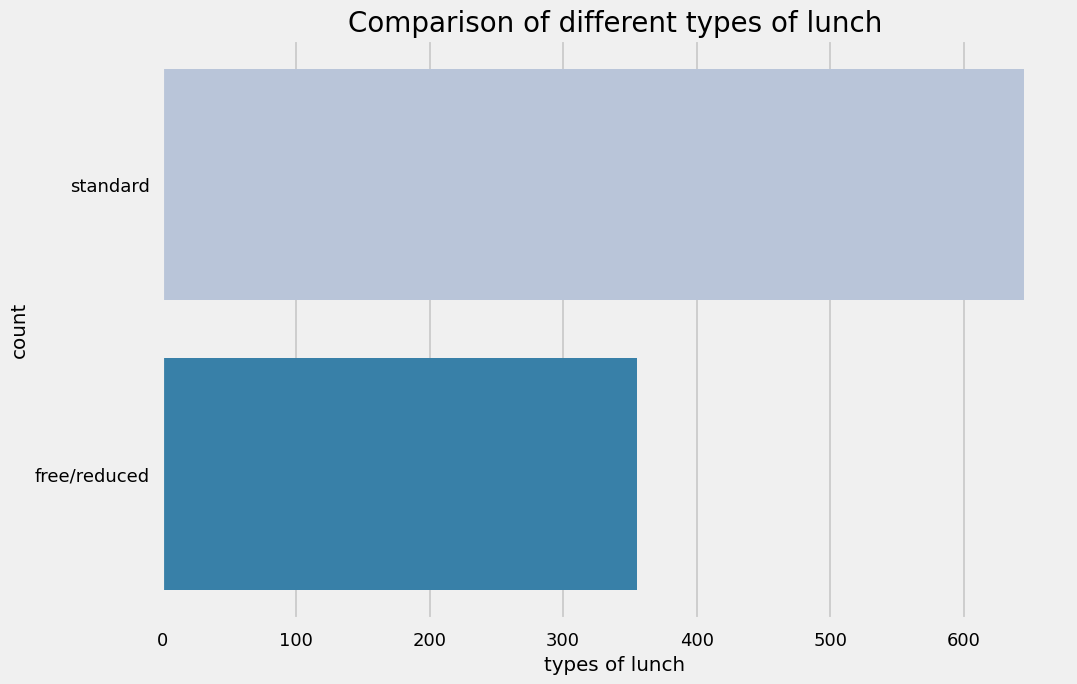

In [83]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

Students being served Standard lunch was more than free lunch.

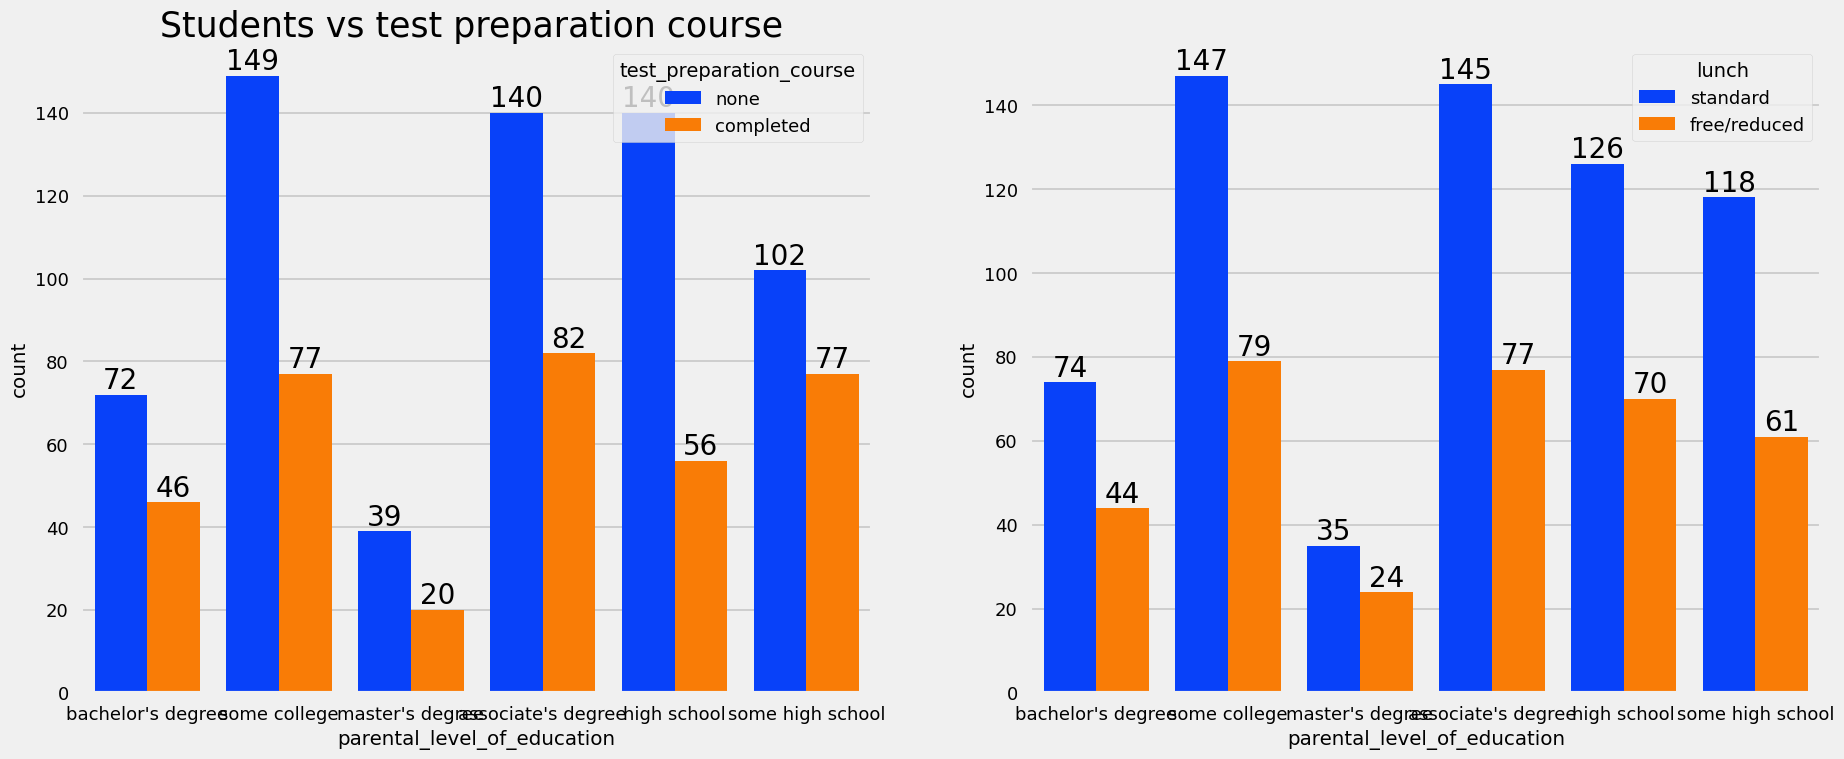

In [84]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',
              saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20) 

Students who get Standard Lunch tend to perform better than students who got free/reduced lunch.

<Axes: xlabel='lunch', ylabel='writing_score'>

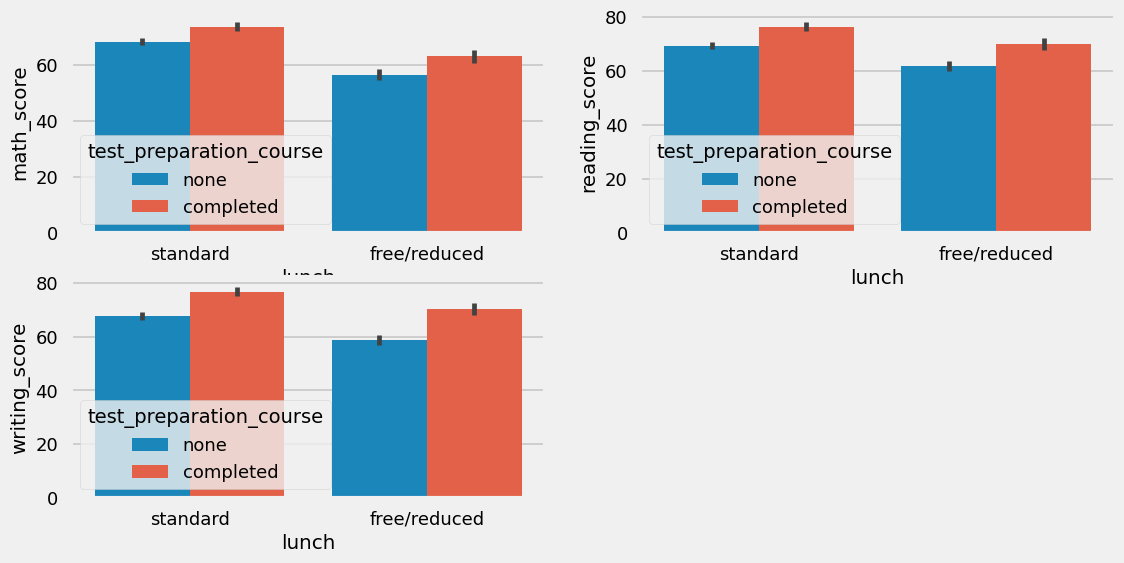

In [86]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course.

### Checking Outliers

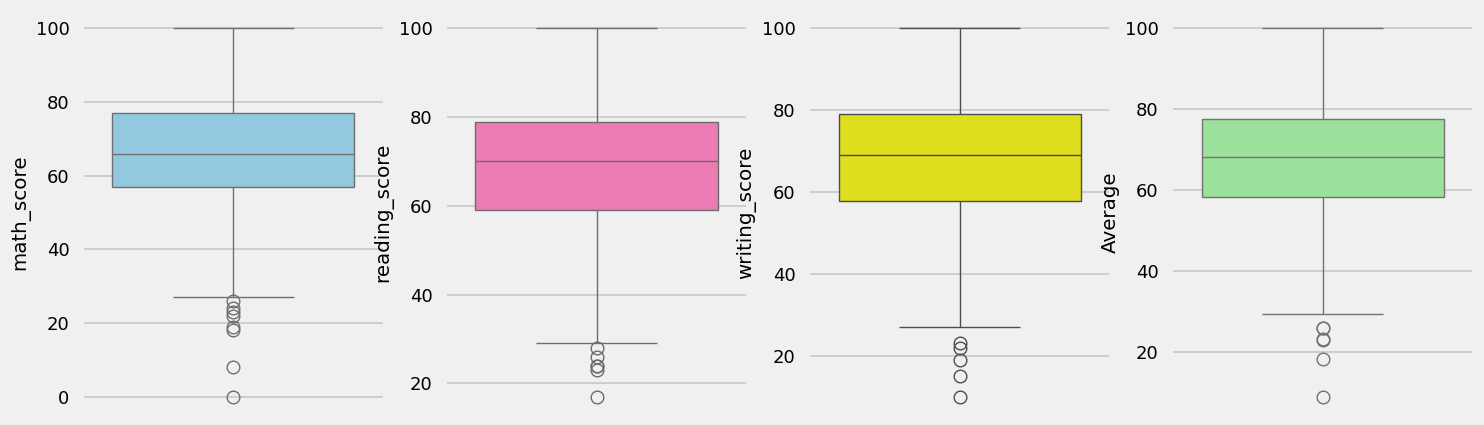

In [87]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average'],color='lightgreen')
plt.show()

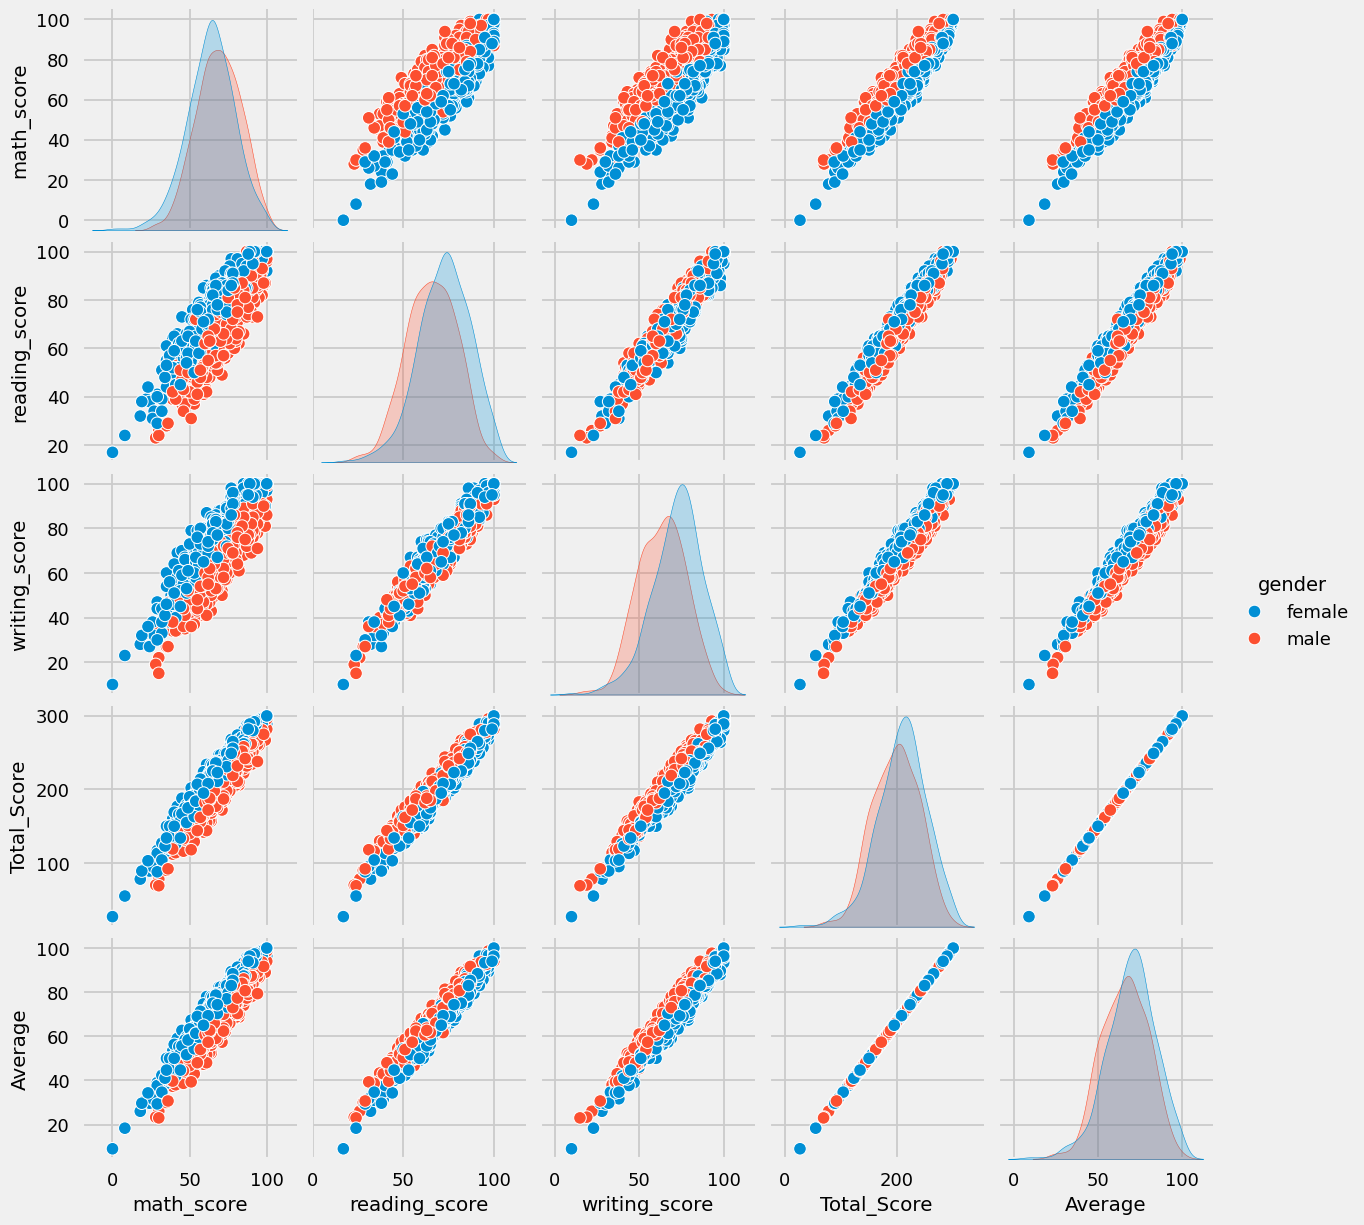

In [88]:
sns.pairplot(df,hue = 'gender')
plt.show()

From the above plot it is clear that all the scores increase linearly with each other.

### Conclusions

- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.